#**1. Problem Understanding & Framing**

According to the Rural Bankers' Association of the Philippines, rural banks serve as critical "last-mile" financial channels that drive grassroots economic growth and financial inclusion.  They are present in remote and lower-income municipalities and have the greatest potential impact on the local communities they serve.  Among the philippine rural banks most crucial functions are:
1. Advancing Financial Inclusion: Operating in municipalities deemed unviable by commercial banks, they bring basic services to unbanked populations.
2. Supporting Countryside Development: Channeling credit directly to small-scale farmers, fisherfolk, and micro-entrepreneurs.
3. Serving as Government Conduits: Acting as distribution points for public financial aid and agricultural credit programs.
4. Acting as Local Financial Mobilizers: Accepting local savings and deposits to reinvest back into the immediate rural community.

In terms of technology adoption, Rural banks are seen to lag behind their Universal,  Commercial, Thrift and Digital banking coutnerparts.  Rural banks more often than not, have the following limitations:
- Limited tech budgets
- Poor remote internet connectivity
- Acute shortages in IT talent
- Heavy reliance on legacy and manual systems

Because of this technology lag, smaller rural banks with fewer resources are not able to capitalize on recent financial inclusion breakthroughs such as the use of financial platform engagement, utility payment histories and mobile top-up habits in scoring unbanked applicants.



**PROJECT OBJECTIVE**: is to create a proof-of-concept alternative credit scoring algorithm for rural banks.  This algorithm will take into account non-traditional parameters such as electronic money use, utility payments and mobile use.  The goal is to provide a lightweight framework which can be customized very rapidly for a particular bank's dataset, processes and risk appetite.

Credit scoring is basically a **BINARY CLASSIFICATION** machine learning problem.  The goal is to predict whether an applicant is a good borrower, or a default risk.  What's peculiar about credit scoring is that we are more interested in the ability to correctly predict the MINORITY or decline/default class in order to safeguard or improve the lender's loans portfolio.  The success metrics for this model is NOT the traditional overall Accuracy score, but the metrics for the MINORITY class:
- **PRECISON**: % of actual decline/default that were correct
- **RECALL**: % of actual decline/default predicted
- **F1 SCORE**: which balanced Precision & Recall in a single score

BUSINESS IMPACT include:
- from UPLIFT approval of loan applications that would have been rejected using traditional evaluation, and,
- loan PORTFOLIO IMPROVEMENT from rejection of applications that would have been approved using traditional parameters, but, rejected upon evaluation with additional data.  

REFERENCES:

https://rbap.org/rural-bankers-association-of-the-philippines-70-years-of-touching-lives-and-promoting-inclusive-development/

https://doi.org/10.62986/pn2026.10

https://www.crif.com/news-events/press/lenddo-and-crif-partner-to-offer-unique-credit-scoring-solution-to-rural-and-savings-banks-in-the-philippines/


#**2. Data Collection & Understanding**

Loan application with approval and denial data is private, confidential and proprietary.  Fortunately, World Bank has a dataset, *The Global Findex Database 2025: Connectivity and Financial Inclusion in the Digital Economy*, which could stand in for loan application information.  Full documentation as well as data dictionary of this set can be found here: https://microdata.worldbank.org/catalog/7860/get-microdata.


DATASET SOURCE ATTRIBUTION:
Development Research Group, Finance and Private Sector Development Unit (World Bank) - The Global Findex
Database 2025: Connectivity and Financial Inclusion in the Digital Economy (FINDEX 2025).
Downloaded from https://microdata.worldbank.org/catalog/7860/get-microdata on 22 September, 2026.

Initially, the Philippine subset of the Findex Database was targeted for use in this project.  However, there are not enough data points (64) for loan application and approval in the Philippine subset.

To boost the number of samples, the Global superset of the Findex dataset will be used.  This data collection has a total of 144,090 cases, 9,691 of which have loan application and approval or denial flags.

This number of datapoints is sufficient to train a classification model.  However, use of a global database restricts immediate use of the resulting model in a local, Philippine setting.  The model would have to be fine-tuned or re-trained with a bank's actual data prior deployment.

The World Bank dataset is comprehensive survey of indicators; it consists of 199 variables across different categories:

| CATEGORY | FEATURES |
|----------|----------|
| Demographic / Psychographic  | 27  |
| Socioeconomic - Traditional  | 68  |
| Socioeconomic - Alternative  | 102 |
| Others (Survey parameters)   | 2   |
| **TOTAL**                    | **199** |

Demographics information include country, population, age, and other classic data points  Traditional Socioeconomic indicators includes such things as household income quintile, credit card ownership and use, and savings.  Alternative indicators include utility payments, frequency of digital transactions and mobile phone and plan ownership.

Next challenge is to narrow down which among these variables are most impactful in our alternative scoring algorithm.

#**3. Data Preprocessing, Applied EDA & Feature Engineering**

ROW FILTERING: out of the 144K+ data points, we will consider only the records where the respondent did apply for a loan (variable 70, "Applied for a loan using a mobile phone").  This cuts out 93% of the records, leaving us with a much more manageable 9,691-record dataset.
In addition, remove any duplicates.

In [ ]:
import pandas as pd

df = pd.read_csv('findex_microdata_2025_labelled_update112425.csv') # Load the dataset

df = df[~df['fin20'].isin([2, 3, 4, pd.NA])]  # remove records where respondent did not apply for a loan
df.dropna(subset=['fin20'], inplace=True)     # remove records with null data in loan application question

print(f"DataFrame shape after filtering: {df.shape}")

df.to_csv('findex_microdata_2025_loans.csv', index=False) # create offline copy of the filtered dataset for future reprocessing

pd.set_option('display.max_columns', None)
display(df.head())

DataFrame shape after filtering: (9691, 199)


,year,economy,economycode,regionwb,pop_adult,wpid_random,wgt,female,age,educ,inc_q,emp_in,urbanicity,account_fin,account_mob,account,dig_account,borrowed,saved,receive_wages,receive_transfers,receive_pensions,receive_agriculture,merchantpay_dig,pay_utilities,domestic_remittances,anydigpayment,fin2,fin3,fin4,fin5,fin6,fin7,fin8,fin9a,fin9b,fin10,fin11_0,fin11_1,fin11_2,fin11a,fin11b,fin11c,fin11d,fin11e,fin11f,fin13_1,fin13a,fin13b,fin13c,fin13d,fin13e,fin13f,fin13f_1,fin14a,fin14b,fin14c,fin14d,fin14e,fin15,fin16,fin17a,fin17b,fin17c,fin17d,fin17e,fin17f,fin18,fin19,fin20,fin21,fin22a,fin22a_1,fin22b,fin22c,fin22d,fin22e,fin22f,fin22g,fin22h,fin23,fin24,fin24a,fin24b,fin24c,fin24d1,fin24d2,fin24d3,fin25e1,fin25e2,fin25e3,fin25e4,fin26a,fin26b,fin27,fh1,fin28,fh2,fin29,fh2a,fin30,fin31a,fin31b,fin31c,fin31d,fin32,fin33,fin34a,fin34b,fin34c,fin34d,fin35,fin36,fin36a,fin37,fin38,fin39a,fin39b,fin39c,fin39d,fin40,fin41,fin41a,fin42,fin43a,fin43b,fin43c,fin43d,fin44,fin45,internet_use,con1,con2a,con2b,con2c,con2d,con2e,con2f,con2g,con3,con4,con5,con6,con7,con8,con9,con10,con11,con12,con13,con14,con15,con16,con17,con18,con19,con20,con21,con22,con23,con24,con25,con26,con27,con28,con29,con30a,con30b,con30c,con30d,con30e,con30f,con30g,con30h,con31a,con31b,con31c,con31d,con31e,con31f,con31g,con31h,con32,fin46,fin47,fin48a,fin48b,fin48c,fin48d,fin48e,fin48f,fin49a,fin49b,fin49c,fin49d,fin49e,fin49f,fin50,fin51
21,2024,Chad,TCD,Sub-Saharan Africa (excluding high income),10289880,111129270,0.386016,2,32,2.0,4.0,1.0,1.0,0,1.0,1,1.0,1.0,1.0,4.0,4.0,4.0,2.0,0.0,4.0,1.0,1.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,2.0,5.0,1.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0,2.0,3.0,1.0,2.0,NaN,2.0,1.0,1.0,2.0,1.0,1.0,NaN,2.0,2.0,2.0,NaN,NaN,NaN,1.0,3.0,3.0,1.0,1.0,2.0,2.0,2.0,2.0,NaN,1.0,2.0,2.0,NaN,1.0,1.0,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,2.0,1.0,NaN,2.0,3.0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0,1.0,NaN,1.0,NaN,1.0,1.0,1.0,1.0,2.0,2.0,NaN,1.0,1,NaN,2.0,1.0,2.0,NaN,1.0,1.0,1.0,1.0,2.0,2.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,2024,Uzbekistan,UZB,Europe & Central Asia (excluding high income),24646062,111146976,0.682036,1,65,3.0,1.0,2.0,2.0,1,NaN,1,1.0,0.0,1.0,1.0,1.0,4.0,4.0,1.0,1.0,3.0,1.0,1,1.0,1.0,2.0,2.0,NaN,1.0,1.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,2.0,NaN,NaN,NaN,1.0,4.0,1.0,2.0,2.0,NaN,2.0,NaN,2.0,2.0,2.0,NaN,NaN,2.0,3.0,3.0,1.0,2.0,NaN,NaN,NaN,1.0,1.0,1.0,NaN,1.0,2.0,NaN,2.0,NaN,2.0,NaN,2.0,1.0,1.0,1.0,NaN,NaN,1.0,2.0,1.0,2.0,NaN,NaN,2.0,1.0,NaN,1.0,2.0,1.0,2.0,NaN,NaN,1.0,2.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,7.0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0,1.0,NaN,1.0,NaN,1.0,2.0,1.0,2.0,2.0,1.0,1.0,2.0,1,NaN,1.0,1.0,1.0,NaN,1.0,1.0,2.0,1.0,9.0,1.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
51,2024,Poland,POL,High income,31148749,111153046,0.820727,1,51,2.0,4.0,1.0,1.0,0,NaN,0,0.0,0.0,1.0,4.0,4.0,4.0,4.0,0.0,4.0,3.0,0.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0,2.0,2.0,1.0,NaN,2.0,1.0,2.0,2.0,NaN,2.0,2.0,2.0,2.0,2.0,NaN,NaN,2.0,3.0,3.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,5.0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
66,2024,Paraguay,PRY,Latin America & Caribbean (excluding high income),487

In [ ]:
print(f"Number of duplicate rows in df: {df.duplicated().sum()}")

Number of duplicate rows in df: 0


NOTE: there are no duplicates in our dataset

FEATURE SELECTION: given we have 9.7K datapoints with an imbalanced dataset (74:26 ratio of approved loans vs declined loans; see database documentation *ddi-documentation-english_microdata-7860.pdf*) we will use the Events Per Variable (EPV) rule of thumb to target the number of features in our model:

- 9,691 * 26.2% declined rate = 2,537 minority class
- 2,537 minority class / 15 to 20  EPV = 132 to 169 maximum features

NOTE that this is a MAX figure, a robust model could be created with fewer than this maximum number.

In [ ]:
# Reload the loans subset of Findex from previous checkpoint
import pandas as pd
df = pd.read_csv('findex_microdata_2025_loans.csv')
print(f"Loans DataFrame reloaded: {df.shape}")

Loans DataFrame reloaded: (9691, 199)


FEATURE SELECTION STEPS:
1. Remove **prohibited attributes**: demographics or socioeconomic indicators that could perpetuate bias such as race, color, religion, national origin, sex, marital status & age.  SOURCE: US Equal Credit Opportunity Act (ECOA).  Also drop features that are Findex survey constants (e.g. Year, Applied for Loan Indicator).  Add to dropped columns irrelevant attributes such as occurences of calamity.  See FeatureSelection.pdf for list and rationale for excluding these columns.
2. Review of the dataset documentation reveal a large number of variables are sparsely populated.  **Drop columns with > 50% NULL values** to avoid adding noise and non-organic bias to the dataset, and, to simplify training.
3. Perform **domain grouping** on the features with values that are insignificant (less than 5%) to control number of dummy variables once we do one-hot encoding.
4. Use **Chi-square test of association** to determine if each of the remaining attributes are statistically relevant to our target variable


In [ ]:
#1 Drop COA, constants and other irrelevant columns
columns_to_drop = ["year","economy","economycode","regionwb","pop_adult","female","age","fin15","fin20","fin24c","fin24d1","fin24d2","fin24d3","fin25e4","con15","fin49a","fin49b","fin49c","fin49d","fin49e","fin49f"]
df = df.drop(columns=columns_to_drop, errors='ignore')
print(f"DataFrame shape after dropping columns: {df.shape}")

DataFrame shape after dropping columns: (9691, 178)


In [ ]:
#2 Check for sparsity
import pandas as pd

null_counts = df.isnull().sum()
columns_with_nulls = null_counts[null_counts > 0].sort_values(ascending=False)

if not columns_with_nulls.empty:
    print("Columns with null values and their percentages:")
    null_percentages = (columns_with_nulls / len(df)) * 100       # Calculate percentage of nulls
    high_null_columns = null_percentages[null_percentages >= 50]  # Filter for columns with >= 50% null values

    if not high_null_columns.empty:
        print("Columns with >= 50% null values and their percentages:")
        pd.set_option('display.max_rows', None)                   # Set option to display all rows
        print(high_null_columns.apply(lambda x: f"{x:.2f}%"))
        pd.reset_option('display.max_rows')
        print(f"\nTotal columns with >= 50% null values: {len(high_null_columns)}")
    else:
        print("No columns found with 50% or more null values.")

    print(f"\nTotal columns in DataFrame: {df.shape[1]}")
else:
    print("No null values found in any of the remaining columns.")

# Drop extremely sparse attributes
if not high_null_columns.empty:
    df = df.drop(columns=high_null_columns.index)
    print(f"\nDropped {len(high_null_columns)} columns with >= 50% null values.")
    print(f"DataFrame shape after dropping sparse columns: {df.shape}")
else:
    print("\nNo columns to drop based on the 50% null value threshold.")

Columns with null values and their percentages:
Columns with >= 50% null values and their percentages:
fin36a      99.99%
fin41a      99.40%
fin43d      98.91%
fin34d      98.86%
fin31c      98.25%
con8        98.24%
con13       98.13%
fin39d      97.45%
con6        97.39%
con5        97.39%
con7        97.39%
fin11b      96.32%
fin11e      96.32%
fin11f      96.32%
fin11d      96.32%
fin11c      96.32%
fin11a      96.32%
fin11_2     96.32%
fin11_1     96.32%
fin11_0     96.32%
fin39c      96.19%
con3        95.97%
con2b       95.62%
con2c       95.62%
con2a       95.62%
con2d       95.62%
con4        95.62%
con2e       95.62%
con2f       95.62%
con2g       95.62%
fin14b      93.17%
fin14c      93.17%
fin16       93.17%
fin14e      93.17%
fin14d      93.17%
fin14a      93.17%
fin48a      93.07%
fin48f      93.07%
fin48c      93.07%
fin48d      93.07%
fin48e      93.07%
fin48b      93.07%
fin34c      91.98%
fin43c      91.54%
con29       91.38%
fin7        90.85%
fin31d      87.66%
fin4

In [ ]:
# 2 Sparsity Check (cont'd): inspect mean / median to see possible default values for NULL fields
pd.set_option('display.max_columns', None) # Ensure all columns are displayed
print(df.describe(include='all'))
pd.reset_option('display.max_columns') # Reset option after displaying

        wpid_random          wgt         educ        inc_q       emp_in  \
count  9.691000e+03  9691.000000  9659.000000  9456.000000  8847.000000   
mean   1.611437e+08     0.922084     1.953825     3.454209     1.253193   
std    2.896811e+07     0.721651     0.653091     1.392895     0.434865   
min    1.111293e+08     0.103973     1.000000     1.000000     1.000000   
25%    1.359162e+08     0.412080     2.000000     2.000000     1.000000   
50%    1.616337e+08     0.715128     2.000000     4.000000     1.000000   
75%    1.862319e+08     1.195411     2.000000     5.000000     2.000000   
max    2.111061e+08     5.251835     3.000000     5.000000     2.000000   

        urbanicity  account_fin  account_mob      account  dig_account  \
count  9567.000000  9691.000000  7721.000000  9691.000000  9691.000000   
mean      1.434410     0.690022     0.715063     0.877412     0.825611   
std       0.495705     0.462508     0.451414     0.327981     0.379463   
min       1.000000     0.000

In [ ]:
#2b impute values where NULL; display columns for imputation

remaining_null_counts = df.isnull().sum()
remaining_columns_with_nulls = remaining_null_counts[remaining_null_counts > 0].sort_values(ascending=False)

if not remaining_columns_with_nulls.empty:
    print("Remaining columns with NULL values, their counts, and percentages:")
    remaining_null_percentages = (remaining_columns_with_nulls / len(df)) * 100
    # Correctly construct null_summary_df using only the filtered columns
    null_summary_df = pd.DataFrame({"Null Count": remaining_columns_with_nulls, "Null Percentage": remaining_null_percentages})
    pd.set_option('display.max_rows', None)

    display_df = null_summary_df.copy()
    display_df['Null Count'] = display_df['Null Count'].astype(int).astype(str)
    display_df['Null Percentage'] = display_df['Null Percentage'].map(lambda x: f'{x:.2f}%')
    print(display_df)

    pd.reset_option('display.max_rows')
    print(f"\nTotal remaining columns with NULL values: {len(remaining_columns_with_nulls)}")

else:
    print("No remaining columns have NULL values.")

Remaining columns with NULL values, their counts, and percentages:
                     Null Count Null Percentage
con19                      4700          48.50%
fin6                       4689          48.39%
fin5                       4689          48.39%
fin31a                     4673          48.22%
fin31b                     4673          48.22%
fin25e3                    4420          45.61%
fin17f                     4189          43.23%
fin17e                     4189          43.23%
fin22a_1                   4144          42.76%
fin17b                     4144          42.76%
con26                      4036          41.65%
con27                      4036          41.65%
con30b                     3751          38.71%
con30a                     3751          38.71%
con30e                     3751          38.71%
con30g                     3751          38.71%
con30h                     3751          38.71%
con30d                     3751          38.71%
con30f               



In [ ]:
#2b: imputation (cont'd): inspect distribution plots for each remaining feature with NULL values to better decide what default value to use in NULL fields

import matplotlib.pyplot as plt
import seaborn as sns

columns_to_plot = remaining_columns_with_nulls.index.tolist()
num_columns = len(columns_to_plot)    # Determine a suitable grid size for plotting
num_rows = (num_columns + 2) // 3     # Roughly 3 plots per row

plt.figure(figsize=(20, num_rows * 6))

for i, column in enumerate(columns_to_plot):
    ax = plt.subplot(num_rows, 3, i + 1)
    # Removed 'order=df[column].value_counts().index' to preserve original x-axis order
    sns.countplot(x=column, data=df, ax=ax, hue=column, palette='viridis', legend=False)

    for container in ax.containers:     # Add count labels on top of the bars
        ax.bar_label(container, fmt='%d', padding=3)

    ax.set_title(f'Distribution of {column} (with NULLs)')
    ax.set_xlabel(column)
    ax.set_ylabel('Count')
    if df[column].nunique() > 5:      # Rotate x-axis labels if they overlap
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

NOTE: there are no outliers as the data is all discrete integers (multiple choice answers)

In [ ]:
#2b: imputation (cont'd): fill in the missing NULL values
# use supermajority value where available in the other sets; e.g. if "YES" > 2/3 of values, then use "YES" as the default value
# where there is no clear pattern in the data, use the equivalent of "I DON'T KNOW" so as not to introduce any unnatural patterns in the data
# see "rationale column" in 'findex_microdata_2025_loans-ImputationDefaults.csv' for details
imputation_defaults_df = pd.read_csv('findex_microdata_2025_loans-ImputationDefaults.csv')
print("Loaded 'findex_microdata_2025_loans-ImputationDefaults.csv' successfully.")
display(imputation_defaults_df.head())

for index, row in imputation_defaults_df.iterrows():  # Impute NULL values in df
    column_name = row['Column']
    default_value = row['default']
    if column_name in df.columns:
        df[column_name] = df[column_name].fillna(default_value)
        print(f"Imputed column '{column_name}' with default value '{default_value}'.")
    else:
        print(f"Warning: Column '{column_name}' not found in df. Skipping imputation for this column.")

# Verify that the specified columns no longer have NULL values;  Filter for only the columns that were supposed to be imputed
imputed_columns_check = imputation_defaults_df['Column'].tolist()
nulls_after_imputation = df[df.columns.intersection(imputed_columns_check)].isnull().sum()
nulls_after_imputation = nulls_after_imputation[nulls_after_imputation > 0]

if not nulls_after_imputation.empty:
    print("\nSome columns still contain NULL values after imputation:")
    print(nulls_after_imputation)
else:
    print("\nAll specified columns were successfully imputed with no remaining NULL values.")

# Export the updated DataFrame to a new CSV file
output_filename = "findex_microdata_2025_loans-Imputed.csv"
df.to_csv(output_filename, index=False)
print(f"\nDataFrame successfully exported to '{output_filename}'.")

Loaded 'findex_microdata_2025_loans-ImputationDefaults.csv' successfully.


,Column,default,rationale
0,con19,8,"Set to ""Don't Know"""
1,fin6,5,"Set to ""Don't Know"""
2,fin5,5,"Set to ""Don't Know"""
3,fin31b,3,"Set to ""Don't Know"""
4,fin31a,3,"Set to ""Don't Know"""


Imputed column 'con19' with default value '8'.
Imputed column 'fin6' with default value '5'.
Imputed column 'fin5' with default value '5'.
Imputed column 'fin31b' with default value '3'.
Imputed column 'fin31a' with default value '3'.
Imputed column 'fin25e3' with default value '4'.
Imputed column 'fin17e' with default value '3'.
Imputed column 'fin17f' with default value '3'.
Imputed column 'fin17b' with default value '3'.
Imputed column 'fin22a_1' with default value '3'.
Imputed column 'con26' with default value '8'.
Imputed column 'con27' with default value '8'.
Imputed column 'con30e' with default value '8'.
Imputed column 'con30b' with default value '8'.
Imputed column 'con30a' with default value '8'.
Imputed column 'con30g' with default value '8'.
Imputed column 'con30h' with default value '8'.
Imputed column 'con30f' with default value '8'.
Imputed column 'con30c' with default value '8'.
Imputed column 'con30d' with default value '8'.
Imputed column 'con16' with default value '8

In [ ]:
# reload df from last checkpoint
import pandas as pd
df = pd.read_csv('findex_microdata_2025_loans-Imputed.csv')
print(f"DataFrame loaded successfully. Shape: {df.shape}")
display(df.head())

DataFrame loaded successfully. Shape: (9691, 87)


,wpid_random,wgt,educ,inc_q,emp_in,urbanicity,account_fin,account_mob,account,dig_account,...,con30a,con30b,con30c,con30d,con30e,con30f,con30g,con30h,fin46,fin47
0,111129270,0.386016,2.0,4.0,1.0,1.0,0,1.0,1,1.0,...,1.0,1.0,1.0,1.0,2.0,2.0,1.0,2.0,1.0,2.0
1,111146976,0.682036,3.0,1.0,2.0,2.0,1,1.0,1,1.0,...,1.0,1.0,2.0,1.0,9.0,1.0,2.0,2.0,1.0,1.0
2,111153046,0.820727,2.0,4.0,1.0,1.0,0,1.0,0,0.0,...,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,1.0,2.0
3,111158827,0.993372,3.0,3.0,1.0,1.0,1,1.0,1,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0
4,111179085,1.298775,3.0,3.0,1.0,2.0,1,1.0,1,1.0,...,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,1.0,2.0


In [ ]:
#3 domain grouping: create list of features with values that comprise less than 5% of the total for that variable

threshold_pct = 0.05
rare_value_columns = []
rare_value_details = {}

cols_to_exclude = ['wpid_random', 'wgt']    # exclude

for col in df.columns:
    if col in cols_to_exclude:
        continue

    value_percentages = df[col].value_counts(normalize=True)            # Calculate the percentage representation of each unique value in the column
    rare_values = value_percentages[value_percentages < threshold_pct]  # Filter for values that appear less than 5% of the time

    if not rare_values.empty:
        rare_value_columns.append(col)
        rare_value_details[col] = rare_values

print(f"Total columns with rare values (< 5% frequency): {len(rare_value_columns)}\n")

for col in rare_value_columns:                    # Display the rare values look like
    print(f"Column '{col}' has rare values:")
    for val, pct in rare_value_details[col].items():
        print(f"  - Value {val}: {pct*100:.2f}%")
    print("-" * 30)

print("\nFull list of columns with rare values:") # Display the full list of columns
print(rare_value_columns)

# export column name, rare value & percentage for offline evaluation
import pandas as pd

# Prepare data for DataFrame
rare_data_rows = []
for col, series in rare_value_details.items():
    for val, pct in series.items():
        rare_data_rows.append({
            'Column': col,
            'Rare_Value': val,
            'Proportion': pct
        })

# Convert to DataFrame
rare_values_df = pd.DataFrame(rare_data_rows)

# Export to CSV
csv_filename = 'rare_value_details.csv'
rare_values_df.to_csv(csv_filename, index=False)

print(f"Successfully exported to '{csv_filename}'.")
display(rare_values_df.head())

Total columns with rare values (< 5% frequency): 71

Column 'receive_wages' has rare values:
  - Value 3.0: 0.80%
------------------------------
Column 'receive_transfers' has rare values:
  - Value 3.0: 1.91%
  - Value 2.0: 1.01%
  - Value 5.0: 0.39%
------------------------------
Column 'receive_pensions' has rare values:
  - Value 3.0: 0.69%
  - Value 2.0: 0.43%
  - Value 5.0: 0.18%
------------------------------
Column 'receive_agriculture' has rare values:
  - Value 3.0: 1.20%
  - Value 5.0: 0.14%
------------------------------
Column 'pay_utilities' has rare values:
  - Value 3.0: 2.63%
------------------------------
Column 'domestic_remittances' has rare values:
  - Value 4.0: 0.07%
------------------------------
Column 'fin2' has rare values:
  - Value 4: 0.20%
  - Value 3: 0.15%
------------------------------
Column 'fin3' has rare values:
  - Value 4.0: 0.04%
------------------------------
Column 'fin4' has rare values:
  - Value 3.0: 0.34%
  - Value 4.0: 0.05%
--------------

,Column,Rare_Value,Proportion
0,receive_wages,3.0,0.008049
1,receive_transfers,3.0,0.019090
2,receive_transfers,2.0,0.010112
3,receive_transfers,5.0,0.003921
4,receive_pensions,3.0,0.006914


In [ ]:
#3 domain grouping (cont'd): after inspecting the rare values, data dict was used to decide which values to combine
# disposition is in rare_value_replacement.csv
import pandas as pd

rare_value_replacement_df = pd.read_csv('rare_value_replacement.csv')
print(f"Loaded 'rare_value_replacement.csv'. Shape: {rare_value_replacement_df.shape}")
display(rare_value_replacement_df.head())

# Replace rare values with replacement values based on the mapping
replacements_made = 0
for index, row in rare_value_replacement_df.iterrows():
    col = row['Column']
    rare_val = row['Rare_Value']
    repl_val = row['Replacement_Value']

    if col in df.columns:
        df[col] = df[col].replace(rare_val, repl_val)
        replacements_made += 1

print(f"\nSuccessfully applied {replacements_made} replacement rules to df.")

Loaded 'rare_value_replacement.csv'. Shape: (114, 5)


,Column,Rare_Value,Proportion,Replacement_Value,Rationale
0,receive_wages,3,0.80%,5,"Set to ""Don't Know"""
1,receive_transfers,3,1.91%,4,"Set to ""Did not""; interpret as did not receive..."
2,receive_transfers,2,1.01%,4,"Set to ""Did not""; interpret as did not receive..."
3,receive_transfers,5,0.39%,4,"Set to ""Did not""; interpret as did not receive..."
4,receive_pensions,3,0.69%,4,"Set to ""Did not""; interpret as did not receive..."



Successfully applied 114 replacement rules to df.


In [ ]:
#3 domain grouping (cont'd): Re-evaluate rare values after applying replacements
threshold_pct = 0.05
remaining_rare_columns = []
remaining_rare_details = {}

cols_to_exclude = ['wpid_random', 'wgt']

for col in df.columns:
    if col in cols_to_exclude:
        continue

    value_percentages = df[col].value_counts(normalize=True)
    rare_values = value_percentages[value_percentages < threshold_pct]

    if not rare_values.empty:
        remaining_rare_columns.append(col)
        remaining_rare_details[col] = rare_values

print(f"Total columns STILL with rare values (< 5% frequency): {len(remaining_rare_columns)}\n")

if remaining_rare_columns:
    for col in remaining_rare_columns:
        print(f"Column '{col}' still has rare values:")
        for val, pct in remaining_rare_details[col].items():
            print(f"  - Value {val}: {pct*100:.2f}%")
        print("-" * 30)
else:
    print("All rare values have been successfully handled!")

# save current contents of df as a checkpoint
df.to_csv('findex_microdata_2025_loans-DomainGrouped.csv', index=False)
print("DataFrame successfully saved to 'findex_microdata_2025_loans-DomainGrouped.csv'.")

Total columns STILL with rare values (< 5% frequency): 0

All rare values have been successfully handled!
DataFrame successfully saved to 'findex_microdata_2025_loans-DomainGrouped.csv'.




In [ ]:
# 3domain grouping (cont'd): inspect distribution plots to ensure that data was not corrupted during domain grouping
import matplotlib.pyplot as plt
import seaborn as sns

cols_to_exclude = ['wpid_random', 'wgt']
cols_to_plot = [col for col in df.columns if col not in cols_to_exclude]

num_columns = len(cols_to_plot)
num_cols_grid = 4
num_rows_grid = (num_columns + num_cols_grid - 1) // num_cols_grid

plt.figure(figsize=(24, num_rows_grid * 5))

for i, column in enumerate(cols_to_plot):
    ax = plt.subplot(num_rows_grid, num_cols_grid, i + 1)

    # Sort the unique values to arrange bars by actual value
    sorted_values = sorted(df[column].dropna().unique())

    sns.countplot(
        x=column,
        data=df,
        ax=ax,
        order=sorted_values,
        palette='viridis',
        hue=column,
        legend=False
    )

    for container in ax.containers:     # Add count labels on top of the bars
        ax.bar_label(container)

    ax.set_title(f'Distribution of {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Count')

    # Rotate x-axis labels if there are many categories
    if len(sorted_values) > 5:
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
#4 Chi-Square test of association; target p-value of 0.25 or less
import pandas as pd
from scipy.stats import chi2_contingency

dependent_variable = 'fin21'    # Dependent variable
columns_to_exclude = ['wpid_random', 'wgt', dependent_variable]   # Columns to exclude from independent variables
independent_variables = [col for col in df.columns if col not in columns_to_exclude]  # Get list of independent variables (all columns except excluded ones)

print(f"Performing Chi-square test of association against dependent variable: '{dependent_variable}'\n")

chi_square_results = []

for col in independent_variables:
    contingency_table = pd.crosstab(df[col], df[dependent_variable])    # Create a contingency table
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)  # Perform Chi-square test
    min_expected_frequency = expected.min()                             # Check for minimum expected frequency
    min_expected_check = True if min_expected_frequency >= 5 else False

    result = {
        'Independent Variable': col,
        'Chi2 Statistic': chi2,
        'P-value': p_value,
        'Degrees of Freedom': dof,
        'Min Expected Frequency': min_expected_frequency,
        'Min Expected Frequency Met (>=5)': min_expected_check
    }
    chi_square_results.append(result)

    print(f"--- Results for '{col}' vs '{dependent_variable}' ---")
    print(f"Chi-square Statistic: {chi2:.4f}")
    print(f"P-value: {p_value:.4f}")
    print(f"Degrees of Freedom: {dof}")
    print(f"Minimum Expected Frequency: {min_expected_frequency:.2f}")
    if not min_expected_check:
        print("WARNING: Minimum expected frequency is less than 5. Chi-square test results may be unreliable.")
    print("\n")

# display all results in a DataFrame
chi_square_df = pd.DataFrame(chi_square_results)
print("Summary of Chi-square Tests:")
display(chi_square_df.sort_values(by='P-value'))

# Suggest columns to keep and drop based on p-value threshold
p_value_threshold = 0.25
columns_to_keep = chi_square_df[chi_square_df['P-value'] < p_value_threshold]['Independent Variable'].tolist()
columns_to_drop_suggested = chi_square_df[chi_square_df['P-value'] >= p_value_threshold]['Independent Variable'].tolist()

print(f"\n--- Feature Selection Suggestion (P-value < {p_value_threshold}) ---")
print("Suggested columns to KEEP (P-value < 0.25):")
print(columns_to_keep)
print("\nSuggested columns to DROP (P-value >= 0.25):")
print(columns_to_drop_suggested)

Performing Chi-square test of association against dependent variable: 'fin21'

--- Results for 'educ' vs 'fin21' ---
Chi-square Statistic: 118.0072
P-value: 0.0000
Degrees of Freedom: 2
Minimum Expected Frequency: 485.62


--- Results for 'inc_q' vs 'fin21' ---
Chi-square Statistic: 128.1650
P-value: 0.0000
Degrees of Freedom: 4
Minimum Expected Frequency: 307.88


--- Results for 'emp_in' vs 'fin21' ---
Chi-square Statistic: 58.3471
P-value: 0.0000
Degrees of Freedom: 1
Minimum Expected Frequency: 588.95


--- Results for 'urbanicity' vs 'fin21' ---
Chi-square Statistic: 5.7017
P-value: 0.0169
Degrees of Freedom: 1
Minimum Expected Frequency: 1092.71


--- Results for 'account_fin' vs 'fin21' ---
Chi-square Statistic: 103.2692
P-value: 0.0000
Degrees of Freedom: 1
Minimum Expected Frequency: 789.82


--- Results for 'account_mob' vs 'fin21' ---
Chi-square Statistic: 91.9376
P-value: 0.0000
Degrees of Freedom: 1
Minimum Expected Frequency: 578.43


--- Results for 'account' vs 'fin21' 

,Independent Variable,Chi2 Statistic,P-value,Degrees of Freedom,Min Expected Frequency,Min Expected Frequency Met (>=5)
33,fin22a,586.017115,1.841821e-129,1,1040.128779,True
34,fin22a_1,281.176313,8.776864e-62,2,670.982974,True
8,borrowed,225.193749,6.661209e-51,1,166.694046,True
45,fin26a,180.915407,5.184640e-40,2,282.380766,True
30,fin17e,173.843611,1.779670e-38,2,631.544319,True
...,...,...,...,...,...,...
70,con23,0.625902,4.288624e-01,1,438.557837,True
55,fin38,0.548846,4.587896e-01,1,175.633474,True
29,fin17c,0.142996,7.053202e-01,1,815.854298,True
54,fin37,0.079164,7.784339e-01,1,333.388092,True



--- Feature Selection Suggestion (P-value < 0.25) ---
Suggested columns to KEEP (P-value < 0.25):
['educ', 'inc_q', 'emp_in', 'urbanicity', 'account_fin', 'account_mob', 'account', 'dig_account', 'borrowed', 'saved', 'receive_wages', 'receive_transfers', 'receive_pensions', 'merchantpay_dig', 'pay_utilities', 'domestic_remittances', 'anydigpayment', 'fin2', 'fin3', 'fin4', 'fin5', 'fin6', 'fin8', 'fin9a', 'fin9b', 'fin10', 'fin17a', 'fin17b', 'fin17e', 'fin17f', 'fin19', 'fin22a', 'fin22a_1', 'fin22b', 'fin22d', 'fin22e', 'fin22f', 'fin24', 'fin24a', 'fin24b', 'fin25e1', 'fin25e2', 'fin25e3', 'fin26a', 'fin26b', 'fh1', 'fh2', 'fh2a', 'fin30', 'fin31a', 'fin31b', 'fin32', 'fin45', 'internet_use', 'con1', 'con9', 'con11', 'con12', 'con14', 'con16', 'con17', 'con18', 'con19', 'con20', 'con21', 'con24', 'con26', 'con27', 'con30a', 'con30b', 'con30c', 'con30d', 'con30e', 'con30f', 'con30g', 'con30h', 'fin46', 'fin47']

Suggested columns to DROP (P-value >= 0.25):
['receive_agriculture', 'f

In [ ]:
#4 Chi-Square (cont'd): drop the identified statistically-irrelevant features

num_cols_to_drop = len(columns_to_drop_suggested)                   # Count the number of columns to drop
print(f"Number of suggested columns to drop: {num_cols_to_drop}")
print(f"Columns to drop: {columns_to_drop_suggested}\n")

features_before = df.shape[1]                                       # Before count of features
print(f"Number of features BEFORE dropping: {features_before}")
df = df.drop(columns=columns_to_drop_suggested, errors='ignore')    # Drop columns from df
features_after = df.shape[1]                                        # After count of features
print(f"Number of features AFTER dropping: {features_after}")
print(f"Successfully dropped {features_before - features_after} columns.")

Number of suggested columns to drop: 6
Columns to drop: ['receive_agriculture', 'fin17c', 'fin37', 'fin38', 'fin42', 'con23']

Number of features BEFORE dropping: 87
Number of features AFTER dropping: 81
Successfully dropped 6 columns.


NOTE: PCA is irrelevant for out dataset because our dataset is composed entirely of categorical variables.  PCA is designed for use with continuous variables.

**EDA & Feature Selection & Engineering Summary:**
- The WB Findex Database rows was filtered select only datapoints with loan application (variable fin20=YES)
- Attributes set was trimmed:
| FEATURE SET | COUNT |
|----------|----------|
| BEGINNING FEATURE SET  | 199  |
| LESS: Prohibited, Constant, Ambiguous/Irrelevantm, ID, Weight, Target  | (24)  |
| LESS: very sparse (> 50% NULL)  | (91) |
| LESS: Statistically Irrelevant (Failed $\chi^2$ Association Test)   | (6)   |
| **FINAL FEATURE SET**                    | **78** |

- The attributes among this 78 with remaining NULL values were imputed with categorical values using predominantly the "Don't know" option, or a Supermajority value where available;  see *findex_microdata_2025_loans-ImputationDefaults.csv* for the imputed values per field and the rationale for each feature

- To further minimize noise, the remaining attributes with values that comprise 5% for that value (rare values) were grouped with other values (mostly "don't know"); see *rare_value_replacement.csv* for the values replaced, the replacement value, and the rationale for choosing the replacement value for each attribute

The **data dictionary** for the dataset to be used for model training is in *JOSEPH_HANS_Pillar_5_Capstone-DataDictionary - FinalAttributesUsedInCapstone.csv*

#**4. Model Implementation**

Trial 3 models for our alternative credit scoring:

*   Lasso with Logistic Regresssion
*   CatBoost
*   XGBoost

In [ ]:
# create train-test split from our cleaned-up dataset
from sklearn.model_selection import train_test_split

y = df['fin21']                                         # Define target variable (y)
X = df.drop(columns=['fin21', 'wpid_random', 'wgt'])    # features (X)
wgt = df['wgt']                                         # weights (wgt)

X_train, X_test, y_train, y_test, wgt_train, wgt_test = train_test_split(
    X, y, wgt, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"wgt_train shape: {wgt_train.shape}")
print(f"wgt_test shape: {wgt_test.shape}")

X_train shape: (7752, 78)
X_test shape: (1939, 78)
y_train shape: (7752,)
y_test shape: (1939,)
wgt_train shape: (7752,)
wgt_test shape: (1939,)


###**4A Lasso Logistic Regression**

In [ ]:
# A. Lasso Logistic Regression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

# Define the preprocessing and modeling pipeline
preprocessor = OneHotEncoder(handle_unknown='ignore')
lasso_model = LogisticRegression(penalty='l1', solver='liblinear', random_state=42, max_iter=1000)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', lasso_model)
])

# Train the pipeline using sample weights (note the classifier__ prefix for the step name)
pipeline.fit(X_train, y_train, classifier__sample_weight=wgt_train)

# Predict on the test set using a lowered decision threshold of 0.4
y_prob = pipeline.predict_proba(X_test)[:, 1]
y_pred = np.where(y_prob >= 0.5, pipeline.classes_[1], pipeline.classes_[0])

# Evaluate the model using test sample weights
accuracy = accuracy_score(y_test, y_pred, sample_weight=wgt_test)
precision = precision_score(y_test, y_pred, sample_weight=wgt_test)
recall = recall_score(y_test, y_pred, sample_weight=wgt_test)
f1 = f1_score(y_test, y_pred, sample_weight=wgt_test)
conf_matrix = confusion_matrix(y_test, y_pred, sample_weight=wgt_test)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)


Accuracy:  0.7365
Precision: 0.7738
Recall:    0.9051
F1 Score:  0.8343

Confusion Matrix:
[[1196.98044994  125.51360453]
 [ 349.93670908  131.85577279]]


In [ ]:
# A2. Lasso Logistic Regression with Balanced Class Weights Optimized for Minority Recall
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, make_scorer

# Define the preprocessing and modeling pipeline
preprocessor = OneHotEncoder(handle_unknown='ignore')

# Initialize Logistic Regression with balanced class weights
log_reg = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', random_state=42, max_iter=1000)

pipeline_cv = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', log_reg)
])

# Define a grid of hyperparameters to search
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100]
}

# Custom scorer to optimize for recall of minority class (2.0)
minority_recall_scorer = make_scorer(recall_score, pos_label=2.0)

print("Starting Grid Search for Logistic Regression (Optimizing for Minority Recall)...")
grid_search_lr = GridSearchCV(estimator=pipeline_cv, param_grid=param_grid, scoring=minority_recall_scorer, cv=3, n_jobs=-1)
grid_search_lr.fit(X_train, y_train)

print(f"Best Parameters: {grid_search_lr.best_params_}")

# Use the best estimator to predict on the test set
best_lr_model = grid_search_lr.best_estimator_
y_pred_best_lr = best_lr_model.predict(X_test)

# Evaluate the improved model
acc_best_lr = accuracy_score(y_test, y_pred_best_lr)
prec_best_lr = precision_score(y_test, y_pred_best_lr)
rec_best_lr = recall_score(y_test, y_pred_best_lr, pos_label=2.0)
f1_best_lr = f1_score(y_test, y_pred_best_lr, pos_label=2.0)
conf_matrix_best_lr = confusion_matrix(y_test, y_pred_best_lr)

print(f"\nTuned LR Accuracy:  {acc_best_lr:.4f}")
print(f"Tuned LR Minority Recall:    {rec_best_lr:.4f}")
print(f"Tuned LR Minority F1 Score:  {f1_best_lr:.4f}")
print("\nTuned LR Confusion Matrix:")
print(conf_matrix_best_lr)

print("\n--- Tuned Lasso Logistic Regression Model (Balanced Weights) Classification Report ---")
print(classification_report(y_test, y_pred_best_lr))

Starting Grid Search for Logistic Regression (Optimizing for Minority Recall)...
Best Parameters: {'classifier__C': 0.01}

Tuned LR Accuracy:  0.6694
Tuned LR Minority Recall:    0.7118
Tuned LR Minority F1 Score:  0.5311

Tuned LR Confusion Matrix:
[[935 494]
 [147 363]]

--- Tuned Lasso Logistic Regression Model (Balanced Weights) Classification Report ---
              precision    recall  f1-score   support

         1.0       0.86      0.65      0.74      1429
         2.0       0.42      0.71      0.53       510

    accuracy                           0.67      1939
   macro avg       0.64      0.68      0.64      1939
weighted avg       0.75      0.67      0.69      1939



In [ ]:
# 4A (Cont'd): compare classification reports of the initial LR model and the fine-tuned LR model
from sklearn.metrics import classification_report

print("--- Lasso Logistic Regression Model ---")
print(classification_report(y_test, y_pred))

print("\n--- Tuned Lasso Logistic Regression Model (Balanced Weights) ---")
print(classification_report(y_test, y_pred_best_lr))

--- Lasso Logistic Regression Model ---
              precision    recall  f1-score   support

         1.0       0.77      0.92      0.84      1429
         2.0       0.50      0.24      0.32       510

    accuracy                           0.74      1939
   macro avg       0.64      0.58      0.58      1939
weighted avg       0.70      0.74      0.70      1939


--- Tuned Lasso Logistic Regression Model (Balanced Weights) ---
              precision    recall  f1-score   support

         1.0       0.86      0.65      0.74      1429
         2.0       0.42      0.71      0.53       510

    accuracy                           0.67      1939
   macro avg       0.64      0.68      0.64      1939
weighted avg       0.75      0.67      0.69      1939



In [ ]:
import joblib

# Define the filename
model_filename = 'JOSEPH_HANS_Pillar_5_Capstone-best_lr_model.pkl'

# Export the model
joblib.dump(best_lr_model, model_filename)
print(f"Model successfully exported to '{model_filename}'")


Model successfully exported to 'JOSEPH_HANS_Pillar_5_Capstone-best_lr_model.pkl'


###**4B CatBoost**

In [ ]:
# B. CatBoost
!pip install -q catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Initialize and train the CatBoost model
cat_model = CatBoostClassifier(random_state=42, verbose=0)
cat_model.fit(X_train, y_train)

# Predict on the test set
y_pred_cat = cat_model.predict(X_test)

# Evaluate the model
accuracy_cat = accuracy_score(y_test, y_pred_cat)
precision_cat = precision_score(y_test, y_pred_cat)
recall_cat = recall_score(y_test, y_pred_cat)
f1_cat = f1_score(y_test, y_pred_cat)
conf_matrix_cat = confusion_matrix(y_test, y_pred_cat)

print(f"Accuracy:  {accuracy_cat:.4f}")
print(f"Precision: {precision_cat:.4f}")
print(f"Recall:    {recall_cat:.4f}")
print(f"F1 Score:  {f1_cat:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix_cat)


Accuracy:  0.7421
Precision: 0.7693
Recall:    0.9286
F1 Score:  0.8415

Confusion Matrix:
[[1327  102]
 [ 398  112]]


In [ ]:
# B2. Catboost with balanced class weights Optimized for Minority Recall
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, make_scorer

# Initialize CatBoost with balanced class weights
cat_base = CatBoostClassifier(random_state=42, verbose=0, auto_class_weights='Balanced')

# Define a grid of hyperparameters to search
param_grid = {
    'iterations': [100, 200],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1]
}

# Custom scorer to optimize for recall of minority class (2.0)
minority_recall_scorer = make_scorer(recall_score, pos_label=2.0)

print("Starting Grid Search for CatBoost (Optimizing for Minority Recall)...")
grid_search = GridSearchCV(estimator=cat_base, param_grid=param_grid, scoring=minority_recall_scorer, cv=3, n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")

# Use the best estimator to predict on the test set
best_cat_model = grid_search.best_estimator_
y_pred_best_cat = best_cat_model.predict(X_test)

# Evaluate the improved model
acc_best = accuracy_score(y_test, y_pred_best_cat)
prec_best = precision_score(y_test, y_pred_best_cat, pos_label=2.0)
rec_best = recall_score(y_test, y_pred_best_cat, pos_label=2.0)
f1_best = f1_score(y_test, y_pred_best_cat, pos_label=2.0)
conf_matrix_best = confusion_matrix(y_test, y_pred_best_cat)

print(f"\nTuned Model Accuracy:  {acc_best:.4f}")
print(f"Tuned Model Minority Recall:    {rec_best:.4f}")
print(f"Tuned Model Minority F1 Score:  {f1_best:.4f}")
print("\nTuned Confusion Matrix:")
print(conf_matrix_best)

Starting Grid Search for CatBoost (Optimizing for Minority Recall)...
Best Parameters: {'depth': 4, 'iterations': 100, 'learning_rate': 0.05}

Tuned Model Accuracy:  0.6761
Tuned Model Minority Recall:    0.7196
Tuned Model Minority F1 Score:  0.5389

Tuned Confusion Matrix:
[[944 485]
 [143 367]]


In [ ]:
# 4B. (Cont'd): compare classification reports of the initial CatBoost model and the fine-tuned CatBoost model
from sklearn.metrics import classification_report

print("--- Original CatBoost Model ---")
print(classification_report(y_test, y_pred_cat))

print("\n--- Tuned CatBoost Model (Balanced Weights) ---")
print(classification_report(y_test, y_pred_best_cat))


--- Original CatBoost Model ---
              precision    recall  f1-score   support

         1.0       0.77      0.93      0.84      1429
         2.0       0.52      0.22      0.31       510

    accuracy                           0.74      1939
   macro avg       0.65      0.57      0.58      1939
weighted avg       0.70      0.74      0.70      1939


--- Tuned CatBoost Model (Balanced Weights) ---
              precision    recall  f1-score   support

         1.0       0.87      0.66      0.75      1429
         2.0       0.43      0.72      0.54       510

    accuracy                           0.68      1939
   macro avg       0.65      0.69      0.64      1939
weighted avg       0.75      0.68      0.69      1939



In [ ]:
import joblib

# Define the filename
model_filename = 'JOSEPH_HANS_Pillar_5_Capstone-best_cat_model.pkl'

# Export the best CatBoost model
joblib.dump(best_cat_model, model_filename)
print(f"CatBoost model successfully exported to '{model_filename}'")


CatBoost model successfully exported to 'JOSEPH_HANS_Pillar_5_Capstone-best_cat_model.pkl'


##**4C XGBoost**

In [ ]:
# C. XGBoost option
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# XGBoost expects class labels starting from 0, so we shift y_train by subtracting 1
y_train_xgb = y_train - 1

# Initialize and train the XGBoost model
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train_xgb)

# Predict on the test set
y_pred_xgb_raw = xgb_model.predict(X_test)

# Shift predictions back by adding 1 to match y_test labels (1 and 2)
y_pred_xgb = y_pred_xgb_raw + 1

# Evaluate the model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

print(f"Accuracy:  {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall:    {recall_xgb:.4f}")
print(f"F1 Score:  {f1_xgb:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix_xgb)


Accuracy:  0.7308
Precision: 0.7815
Recall:    0.8810
F1 Score:  0.8283

Confusion Matrix:
[[1259  170]
 [ 352  158]]


In [ ]:
# C2. XGBoost option fine tuned Optimized for Minority Recall
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, make_scorer

# Calculate the ratio of negative to positive instances for scale_pos_weight
scale_pos_weight_value = sum(y_train_xgb == 0) / sum(y_train_xgb == 1)
print(f"Calculated scale_pos_weight: {scale_pos_weight_value:.4f}")

# Initialize XGBoost with the balanced weight
xgb_base = xgb.XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=scale_pos_weight_value)

# Define a grid of hyperparameters to search
param_grid_xgb = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200]
}

# For XGBoost, targets are shifted to 0 and 1, where 1 is the minority class
xgb_minority_recall_scorer = make_scorer(recall_score, pos_label=1)

print("Starting Grid Search for XGBoost (Optimizing for Minority Recall)...")
grid_search_xgb = GridSearchCV(estimator=xgb_base, param_grid=param_grid_xgb, scoring=xgb_minority_recall_scorer, cv=3, n_jobs=-1)
grid_search_xgb.fit(X_train, y_train_xgb)

print(f"Best Parameters: {grid_search_xgb.best_params_}")

# Use the best estimator to predict on the test set
best_xgb_model = grid_search_xgb.best_estimator_
y_pred_best_xgb_raw = best_xgb_model.predict(X_test)

# Shift predictions back by adding 1 to match y_test labels (1 and 2)
y_pred_best_xgb = y_pred_best_xgb_raw + 1

# Evaluate the improved model
acc_best_xgb = accuracy_score(y_test, y_pred_best_xgb)
prec_best_xgb = precision_score(y_test, y_pred_best_xgb, pos_label=2.0)
rec_best_xgb = recall_score(y_test, y_pred_best_xgb, pos_label=2.0)
f1_best_xgb = f1_score(y_test, y_pred_best_xgb, pos_label=2.0)
conf_matrix_best_xgb = confusion_matrix(y_test, y_pred_best_xgb)

print(f"\nTuned XGBoost Accuracy:  {acc_best_xgb:.4f}")
print(f"Tuned XGBoost Minority Recall:    {rec_best_xgb:.4f}")
print(f"Tuned XGBoost Minority F1 Score:  {f1_best_xgb:.4f}")
print("\nTuned XGBoost Confusion Matrix:")
print(conf_matrix_best_xgb)

Calculated scale_pos_weight: 2.8037
Starting Grid Search for XGBoost (Optimizing for Minority Recall)...
Best Parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100}

Tuned XGBoost Accuracy:  0.6612
Tuned XGBoost Minority Recall:    0.7255
Tuned XGBoost Minority F1 Score:  0.5297

Tuned XGBoost Confusion Matrix:
[[912 517]
 [140 370]]


In [ ]:
from sklearn.metrics import classification_report

print("--- Original XGBoost Model ---")
print(classification_report(y_test, y_pred_xgb))

print("\n--- Tuned XGBoost Model (Balanced Weights) ---")
print(classification_report(y_test, y_pred_best_xgb))


--- Original XGBoost Model ---
              precision    recall  f1-score   support

         1.0       0.78      0.88      0.83      1429
         2.0       0.48      0.31      0.38       510

    accuracy                           0.73      1939
   macro avg       0.63      0.60      0.60      1939
weighted avg       0.70      0.73      0.71      1939


--- Tuned XGBoost Model (Balanced Weights) ---
              precision    recall  f1-score   support

         1.0       0.87      0.64      0.74      1429
         2.0       0.42      0.73      0.53       510

    accuracy                           0.66      1939
   macro avg       0.64      0.68      0.63      1939
weighted avg       0.75      0.66      0.68      1939



In [ ]:
import joblib

# Define the filename
model_filename = 'JOSEPH_HANS_Pillar_5_Capstone-best_xgb_model.pkl'

# Export the best XGBoost model
joblib.dump(best_xgb_model, model_filename)
print(f"XGBoost model successfully exported to '{model_filename}'")


XGBoost model successfully exported to 'JOSEPH_HANS_Pillar_5_Capstone-best_xgb_model.pkl'


In [ ]:
# Compare metrics for minority class
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

# Helper function to extract metrics for the minority class (2.0)
def get_minority_metrics(y_true, y_pred, minority_class=2.0):
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=[minority_class], average=None)
    return precision[0], recall[0], f1[0]

# Get metrics for each tuned model
lr_prec, lr_rec, lr_f1 = get_minority_metrics(y_test, y_pred_best_lr)
cat_prec, cat_rec, cat_f1 = get_minority_metrics(y_test, y_pred_best_cat)
xgb_prec, xgb_rec, xgb_f1 = get_minority_metrics(y_test, y_pred_best_xgb)

# Create a DataFrame to tabulate the results
metrics_data = {
    'Model': ['Tuned Lasso LR', 'Tuned CatBoost', 'Tuned XGBoost'],
    'Minority Precision': [lr_prec, cat_prec, xgb_prec],
    'Minority Recall': [lr_rec, cat_rec, xgb_rec],
    'Minority F1-Score': [lr_f1, cat_f1, xgb_f1]
}

metrics_df = pd.DataFrame(metrics_data)
metrics_df.set_index('Model', inplace=True)

# Display the table
print("--- Comparison of Minority Class (2.0) Metrics ---")
display(metrics_df.round(4))


--- Comparison of Minority Class (2.0) Metrics ---


,Minority Precision,Minority Recall,Minority F1-Score
Model,,,
Tuned Lasso LR,0.4236,0.7118,0.5311
Tuned CatBoost,0.4308,0.7196,0.5389
Tuned XGBoost,0.4171,0.7255,0.5297


MODEL EVALUATION: of the three tuned models, it is **XGBoost ** that has the best RECALL of the default/decline class.  It's PRECISION is lowest, so there will be more *"approve"* cases that are misclassified as *"decline"*.  This makes the model more **conservative**, which is preferable, especially for small lenders who have limited resources, or, for banks that are just starting with alternative scoring and want to be careful in safeguarding their loan portfolio at the initial stages.

The **Tuned XGBoost is recommended for alternative credit scoring** for Rural Banks.

#**5. Model Audit**
i. SHAP  feature importance  
ii. Lasso L1 Penalty  feature importance  
iii. Model limitations  
iv. Bias and fairness assessment


##**5.i SHAP feature importance**

Generating SHAP summary plot for Tuned XGBoost...


/usr/local/lib/python3.13/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_1465/3562162248.py:32: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


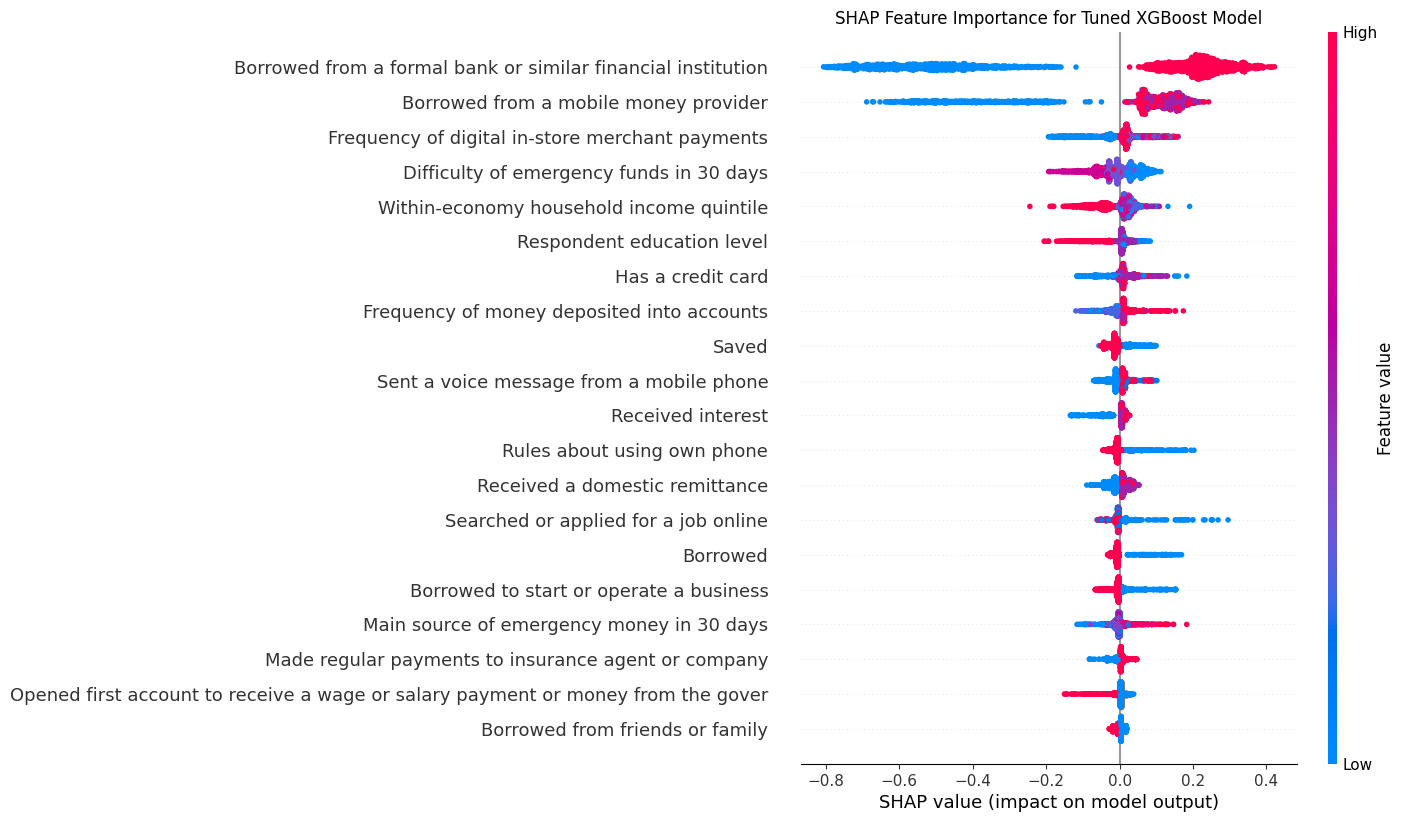

In [ ]:
# 5.i SHAP feature importance for Tuned XGBoost model
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load the column labels to map encoded features to human-readable names
try:
    column_labels_df = pd.read_csv('JOSEPH_HANS_Pillar_5_Capstone-DataDictionary-ColumnLabels.csv')
    column_label_map = dict(zip(column_labels_df['ColumnName'], column_labels_df['Label']))
except Exception as e:
    print(f"Could not load column labels CSV: {e}. Using default column names.")
    column_label_map = {}

# Initialize SHAP TreeExplainer for the best XGBoost model
explainer_xgb = shap.TreeExplainer(best_xgb_model)

# Calculate SHAP values for the test set
shap_values_xgb = explainer_xgb.shap_values(X_test)

# Apply the human-readable feature label mapping
human_readable_features = [column_label_map.get(col, col) for col in X_test.columns]

# Convert test set to DataFrame with readable feature names for plotting
X_test_readable = X_test.copy()
X_test_readable.columns = human_readable_features

print("Generating SHAP summary plot for Tuned XGBoost...")
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values_xgb, X_test_readable, show=False)
plt.title("SHAP Feature Importance for Tuned XGBoost Model")
plt.tight_layout()
plt.show()

SHAP reveals that the top features that contribute to alternative credit worthiness are:

1. **Prior Borrowing Experience** is King: The top two features by far are related to prior loans:  
    - ***Borrowed from a formal bank or similar financial institution***: High values (shown in pink) push the SHAP value to the right (positive impact), indicating that traditional loan history strongly influences the model's output.
    - ***Borrowed from a mobile money provider***: This alternative indicator also plays a massive role—having prior mobile borrowing experience is highly correlated with how the model scores credit risk.

2. **Financial Capacity**:
  - ***Frequency of digital in-store merchant payments*** and Difficulty of getting emergency funds represent highly active indicators of alternative financial health. Those who struggle less to find emergency funds exhibit a distinct impact on model predictions.

3. **Socioeconomic Factors**:
  - ***Within-economy household income quintile*** and ***Respondent education level*** fall right behind, demonstrating that while alternative metrics are very powerful, core economic capacity still acts as a foundational anchor for risk forecasting.

In summary, previous experience with loans, financial capacity and socioeconomic indicators are the most important determinants of credit ratings in our model

##**5.ii LIME feature importance validation**


In [ ]:
# 5.ii LIME feature importance for Tuned XGBoost model

# Install lime library if not already installed
!pip install -q lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


LIME Explanation for Test Instance at index 0:


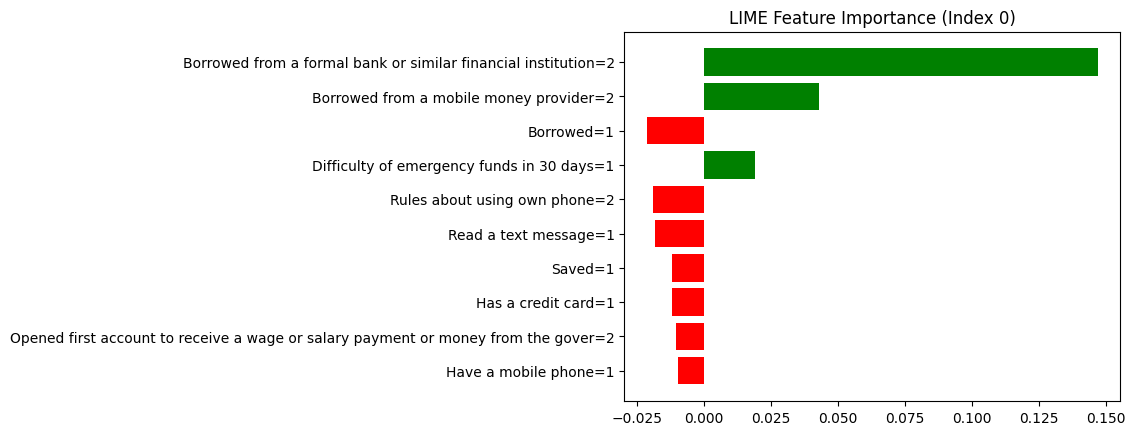

In [ ]:
from lime import lime_tabular
import matplotlib.pyplot as plt

# Prepare feature names and map to human-readable labels
feature_names_list = list(X_test.columns)
human_readable_features = [column_label_map.get(col, col) for col in feature_names_list]

# LIME requires the training data as a numpy array for statistics calculation
X_train_numpy = X_train.values
X_test_numpy = X_test.values

# To prevent scale errors with Scipy's truncnorm, we explicitly pass the indices of all categorical features to LIME
categorical_features_indices = list(range(X_train_numpy.shape[1]))

# Initialize the LIME Tabular Explainer
explainer_lime = lime_tabular.LimeTabularExplainer(
    training_data=X_train_numpy,
    feature_names=human_readable_features,
    categorical_features=categorical_features_indices,  # Treat all features as categorical explicitly
    class_names=['Approved (1)', 'Declined (2)'],
    mode='classification',
    random_state=42
)

# Select an instance from the test set to explain (e.g., the first row)
sample_idx = 0
instance = X_test_numpy[sample_idx]

# Generate explanation for this instance
exp = explainer_lime.explain_instance(
    data_row=instance,
    predict_fn=best_xgb_model.predict_proba,
    num_features=10
)

# Display and plot the LIME explanation
print(f"LIME Explanation for Test Instance at index {sample_idx}:")
fig_lime = exp.as_pyplot_figure()
plt.title(f"LIME Feature Importance (Index {sample_idx})")
# plt.tight_layout()
plt.show()

LIME corroborates SHAP's findings on the importance of **Prior Loans availment** as a sign of creditworthiness.  
**Capacity to pay / Liquidity** also figures prominently in the model's decision.  
Finally, **use of mobile technology** has impact on the algorithm, albeit not specifically use of digital payments as identified by SHAP.

##**5.iii. Model limitations**

1. One upfront, knowon  limitations of this model is the **global nature of the dataset**.  It is not specific to the Philippine context and not specific to rural bank lending.  To address this, the model needs to be **fine-tuned and/or retrained** with a bank's own data.

2. Related to the first item is the use of a **proxy target variable** (Loan Approval)  The model thus mimic's historical underwriting decisions rather than truly predicting true default risk.

3. To protect small rural lenders, the model was tuned to maximize **Minority Recall** (catching as many potential defaults/declines as possible, achieving ~72.5%). Consequently, its Minority Precision dropped to ~41.7%.  This results in a high rate of False Positives. It will flag many creditworthy, low-risk applicants as "high risk" and recommend declining them, which could restrict the bank's loan portfolio growth and deny credit to good borrowers.

4. Since XGBoost is an ensemble tree-based method containing complex non-linear splits, XGBoost is a "**black box**" and will require credit decisions to be explained with computationally expensive SHAP or LIME for each decision.  In contrast, decisions from a linear model like Logistic Regression would have been easier to interpret, just by looking at the model's coefficients.

##**5.iv Bias & Fairness**
- The usual **causes for bias** (gender, age, ethnicity using country of origin as proxy) **were eliminated** early in feature selection as these are prohibited for use in credit scoring algorithms.
- The important features that emerged during model training, though, seemed to **discriminate against the unbanked population**.  The most important features were related to either a) prior financial experience with loans and b) capacity and motivation to pay.  The algorithm thus perpetuates credit to those with existing credit history.  It does not help advance financial inclusivity.
- To address this, we can create an **alternative model** where we drop the traditional financial attributes so that the importance of alternative attributes (e.g. utility payments, rental payments) can emerge.  This exercise is shown in the cells below.
- The recall of this alternative model is 0.61, still better than the proportion of negative cases in our dataset.  However, it is below that of best_xgb_model which includes the traditional financial variables.
- To further improve this model, next step should be to expand dataset to include actual loan repayment data (versus the loan approval target variable that we are limited to currently).





**5.iv.1 Addressing Bias: Focusing on Alternative Financial Trustworthiness Features**

To address the potential bias against unbanked populations, we will modify our feature set by:

*   **Excluding 'Traditional Financial Experience' Features**: These are features that often require prior engagement with formal banking institutions (e.g., having a bank account, borrowing from traditional banks, saving in formal institutions).
*   **Emphasizing 'Alternative Financial Trustworthiness' Features**: These include indicators of financial behavior and discipline through digital transactions, mobile money, and consistent payments (e.g., paying utility bills, using mobile money, making digital merchant payments, managing larger purchases).

This approach aims to create a model that can assess creditworthiness based on broader and more inclusive financial behaviors, rather than solely on formal credit history, which many unbanked individuals lack.*

In [ ]:
# Identify features to drop (traditional financial experience)
traditional_financial_features = [
    'account_fin', # Has an account at a financial institution
    'borrowed',    # Borrowed any money (broad, but often implies formal)
    'saved',       # Saved at a financial institution (broad, but often implies formal)
    'fin17a',      # Received interest on savings
    'fin17b',      # Received interest from a bank or other financial institution
    'fin17c',      # Received interest from a microfinance institution
    'fin17e',      # Received interest from a digital payment service provider
    'fin17f',      # Received interest from a person outside the family
    'fin19',       # Made a deposit into an account at a financial institution
    'fin22a',      # Borrowed from a formal bank or similar financial institution
    'fin22a_1',    # Borrowed from a formal bank or similar financial institution (specific instance)
    'fin22b',      # Borrowed from a microfinance institution
    'fin22d',      # Borrowed from an employer
    'fin22e',      # Borrowed from a digital payment service provider
]

# Filter out features that are not present in the current dataframe X
traditional_financial_features = [col for col in traditional_financial_features if col in X.columns]

print(f"Identified {len(traditional_financial_features)} traditional financial features to drop.")

# Create the new feature set X_alternative by dropping these columns
X_alternative = X.drop(columns=traditional_financial_features, errors='ignore')

print(f"Original feature set shape: {X.shape}")
print(f"Alternative feature set shape: {X_alternative.shape}")

# Re-run train-test split with the new feature set
from sklearn.model_selection import train_test_split
X_train_alt, X_test_alt, y_train_alt, y_test_alt, wgt_train_alt, wgt_test_alt = train_test_split(
    X_alternative, y, wgt, test_size=0.2, random_state=42, stratify=y
)

print(f"\nX_train_alt shape: {X_train_alt.shape}")
print(f"X_test_alt shape: {X_test_alt.shape}")
print(f"y_train_alt shape: {y_train_alt.shape}")
print(f"y_test_alt shape: {y_test_alt.shape}")
print(f"wgt_train_alt shape: {wgt_train_alt.shape}")
print(f"wgt_test_alt shape: {wgt_test_alt.shape}")

Identified 13 traditional financial features to drop.
Original feature set shape: (9691, 78)
Alternative feature set shape: (9691, 65)

X_train_alt shape: (7752, 65)
X_test_alt shape: (1939, 65)
y_train_alt shape: (7752,)
y_test_alt shape: (1939,)
wgt_train_alt shape: (7752,)
wgt_test_alt shape: (1939,)


###**5.iv.2 Re-training XGB with the Alternative Feature Set**

Now, we will re-train our previously selected XGBoost model using this new `X_alternative` feature set. We will compare the minority class metrics (Precision, Recall, F1-Score) to see the impact of this change on addressing bias.

In [ ]:
# Train alternative XGBoost model excluding traditional financial experience features
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, make_scorer
import joblib

# Map target labels: shift from 1 & 2 to 0 & 1 for XGBoost compatibility
y_train_xgb_alt = y_train_alt - 1
y_test_xgb_alt = y_test_alt - 1

# Calculate class imbalance weight ratio
scale_pos_weight_alt_value = sum(y_train_xgb_alt == 0) / sum(y_train_xgb_alt == 1)
print(f"Alternative scale_pos_weight: {scale_pos_weight_alt_value:.4f}")

# Initialize alternative XGBoost base classifier
xgb_base_alt = xgb.XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=scale_pos_weight_alt_value)

# Re-use parameter grid
param_grid_xgb_alt = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200]
}

# Optimize for minority class recall (pos_label=1 representing the shifted '2.0' class)
xgb_minority_recall_scorer = make_scorer(recall_score, pos_label=1)

print("Starting Grid Search for Alternative XGBoost (Optimizing for Minority Recall)...")
grid_search_xgb_alt = GridSearchCV(estimator=xgb_base_alt, param_grid=param_grid_xgb_alt, scoring=xgb_minority_recall_scorer, cv=3, n_jobs=-1)
grid_search_xgb_alt.fit(X_train_alt, y_train_xgb_alt)

print(f"Best Parameters (Alternative Features): {grid_search_xgb_alt.best_params_}")

# Evaluate alternative best model
best_xgb_model_alt = grid_search_xgb_alt.best_estimator_
y_pred_best_xgb_alt_raw = best_xgb_model_alt.predict(X_test_alt)

# Map predictions back to original scale (1.0 & 2.0)
y_pred_best_xgb_alt = y_pred_best_xgb_alt_raw + 1

# Metrics evaluation
acc_best_xgb_alt = accuracy_score(y_test_alt, y_pred_best_xgb_alt)
prec_best_xgb_alt = precision_score(y_test_alt, y_pred_best_xgb_alt, pos_label=2.0)
rec_best_xgb_alt = recall_score(y_test_alt, y_pred_best_xgb_alt, pos_label=2.0)
f1_best_xgb_alt = f1_score(y_test_alt, y_pred_best_xgb_alt, pos_label=2.0)
conf_matrix_best_xgb_alt = confusion_matrix(y_test_alt, y_pred_best_xgb_alt)

print(f"\nAlternative XGBoost Accuracy:  {acc_best_xgb_alt:.4f}")
print(f"Alternative XGBoost Minority Recall:    {rec_best_xgb_alt:.4f}")
print(f"Alternative XGBoost Minority F1 Score:  {f1_best_xgb_alt:.4f}")
print("\nAlternative XGBoost Confusion Matrix:")
print(conf_matrix_best_xgb_alt)

print("\n--- Alternative XGBoost Classification Report ---")
print(classification_report(y_test_alt, y_pred_best_xgb_alt))

# Export the alternative XGBoost model
alt_model_filename = 'JOSEPH_HANS_Pillar_5_Capstone-best_xgb_model_alt.pkl'
joblib.dump(best_xgb_model_alt, alt_model_filename)
print(f"Alternative XGBoost model successfully exported to '{alt_model_filename}'")

Alternative scale_pos_weight: 2.8037
Starting Grid Search for Alternative XGBoost (Optimizing for Minority Recall)...
Best Parameters (Alternative Features): {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}

Alternative XGBoost Accuracy:  0.5972
Alternative XGBoost Minority Recall:    0.6078
Alternative XGBoost Minority F1 Score:  0.4425

Alternative XGBoost Confusion Matrix:
[[848 581]
 [200 310]]

--- Alternative XGBoost Classification Report ---
              precision    recall  f1-score   support

         1.0       0.81      0.59      0.68      1429
         2.0       0.35      0.61      0.44       510

    accuracy                           0.60      1939
   macro avg       0.58      0.60      0.56      1939
weighted avg       0.69      0.60      0.62      1939

Alternative XGBoost model successfully exported to 'JOSEPH_HANS_Pillar_5_Capstone-best_xgb_model_alt.pkl'


Generating SHAP summary plot for Alternative Tuned XGBoost...


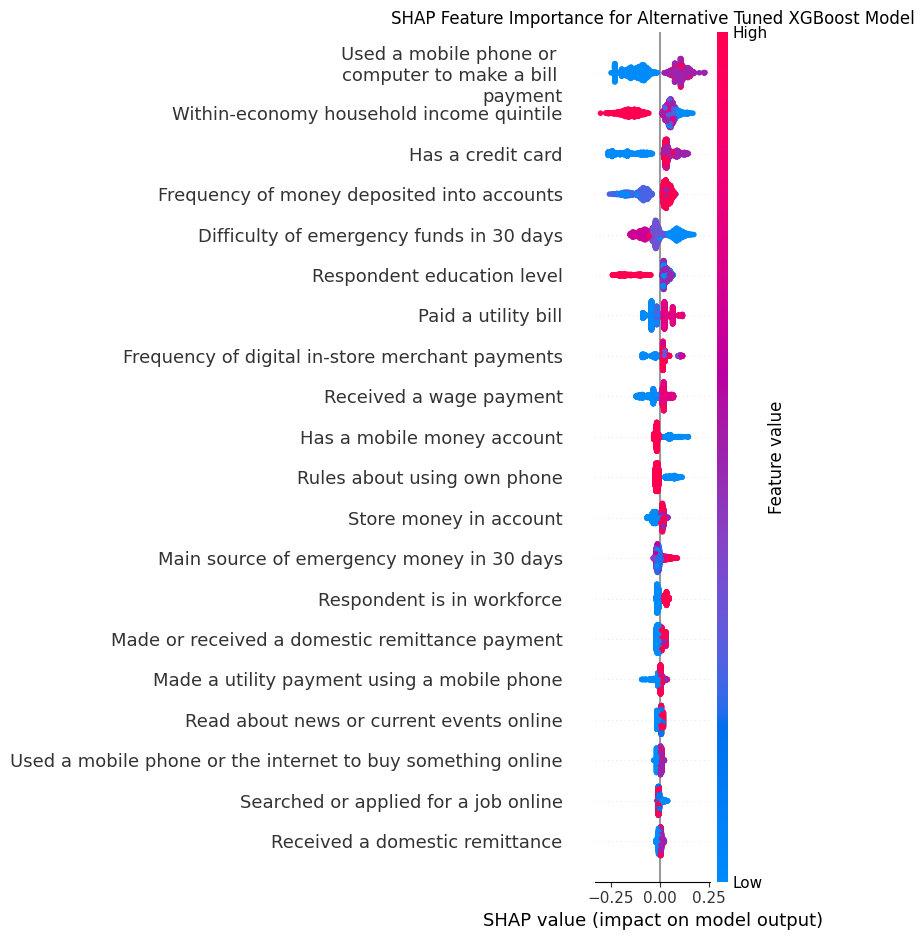

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

# Try to load human-readable feature labels
try:
    column_labels_df = pd.read_csv('JOSEPH_HANS_Pillar_5_Capstone-DataDictionary-ColumnLabels.csv')
    column_label_map = dict(zip(column_labels_df['ColumnName'], column_labels_df['Label']))
except Exception as e:
    print(f"Could not load column labels CSV: {e}. Using default column names.")
    column_label_map = {}

# Initialize SHAP TreeExplainer for the alternative XGBoost model
explainer_xgb_alt = shap.TreeExplainer(best_xgb_model_alt)

# Calculate SHAP values on the alternative test set
shap_values_xgb_alt = explainer_xgb_alt.shap_values(X_test_alt)

# Map the alternative test set columns to human-readable feature labels
human_readable_features_alt = [column_label_map.get(col, col) for col in X_test_alt.columns]

# Create a copy of the alternative test DataFrame with updated columns for the plot
X_test_alt_readable = X_test_alt.copy()
X_test_alt_readable.columns = human_readable_features_alt

# Generate the SHAP Beeswarm summary plot
print("Generating SHAP summary plot for Alternative Tuned XGBoost...")
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values_xgb_alt, X_test_alt_readable, show=False)
plt.title("SHAP Feature Importance for Alternative Tuned XGBoost Model")
plt.tight_layout()
plt.show()

Excluding the traditional financial experience attributes, alternative digital footprint and behavioral indicators are now the new most important factors in this alternative XGBoost algorithm.  In order of importance, these features are:
1. **Digital Payment Activity**:
    - ***Used a mobile phone or computer to make a bill payment*** is now the top-ranking predictor. High values (pink) heavily impact predictions, showing that active engagement with utility and digital bill payments is a strong signal of reliability.
    - ***Frequency of digital in-store merchant payments*** also ranks highly, demonstrating that day-to-day transactional data acts as an excellent proxy for financial activity.

2. **Financial Management & Liquidity**: ***Frequency of money deposited into accounts*** and ***Difficulty of emergency funds in 30 days*** remain crucial indicators. This shows that even without formal borrowing history, a person's regular deposit behaviors and perceived capacity to handle emergencies are powerful indicators of creditworthiness.

3. **Basic Phone & Digital Literacy**: Alternative behaviors like Rules about using own phone and Has a mobile money account are now driving decision boundaries, which validates our approach of looking at mobile engagement patterns to capture "last-mile" unbanked applicants.

4. **Socioeconomic Indicators**: Within-economy household income quintile and Respondent education level still serve as strong foundational controls, ensuring that overall economic capacity is factored in alongside behavioral telemetry.

SUMMARY: This SHAP audit confirms that by dropping traditional credit history, the model successfully shifts its focus to **alternative transactional, digital, and behavioral trustworthiness features**—directly serving our goal of creating a more inclusive scoring algorithm for rural banks!

In [ ]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

# Helper function to extract metrics for the minority class (2.0)
def get_minority_metrics(y_true, y_pred, minority_class=2.0):
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=[minority_class], average=None)
    return precision[0], recall[0], f1[0]

# Extract metrics for original Tuned XGBoost (using original y_test and y_pred_best_xgb)
xgb_prec_orig, xgb_rec_orig, xgb_f1_orig = get_minority_metrics(y_test, y_pred_best_xgb)

# Extract metrics for alternative Tuned XGBoost (using alternative y_test_alt and y_pred_best_xgb_alt)
xgb_prec_alt, xgb_rec_alt, xgb_f1_alt = get_minority_metrics(y_test_alt, y_pred_best_xgb_alt)

# Tabulate the metrics
comparison_data = {
    'Model': ['Original Tuned XGBoost', 'Alternative Tuned XGBoost (No Traditional Financial Features)'],
    'Minority Precision (Class 2.0)': [xgb_prec_orig, xgb_prec_alt],
    'Minority Recall (Class 2.0)': [xgb_rec_orig, xgb_rec_alt],
    'Minority F1-Score (Class 2.0)': [xgb_f1_orig, xgb_f1_alt]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df.set_index('Model', inplace=True)

print("--- Comparison of Minority Class (2.0) Metrics (Original vs. Alternative XGBoost) ---")
display(comparison_df.round(4))


--- Comparison of Minority Class (2.0) Metrics (Original vs. Alternative XGBoost) ---


,Minority Precision (Class 2.0),Minority Recall (Class 2.0),Minority F1-Score (Class 2.0)
Model,,,
Original Tuned XGBoost,0.4171,0.7255,0.5297
Alternative Tuned XGBoost (No Traditional Financial Features),0.3479,0.6078,0.4425


In [ ]:
# INSTRUCTIONS:
# 1. Go to File -> Download -> Download .ipynb
# 2. Upload the downloaded file to the Colab Files pane (left sidebar); make sure it's in the \content folder
# 3. Replace 'YOUR_UPLOADED_NOTEBOOK_NAME.ipynb' below with the actual filename
# 4. Run this cell

# !jupyter nbconvert 'JOSEPH_HANS_Pillar_5_Capstone.ipynb' --to html --output JOSEPH_HANS_Pillar_5_Capstone-TechnicalDeck.html